# Generic April Test-Case Visualization

This notebook analyzes the merged April run suite under `runs/gen_apr0326`.
It reads each run directory's real `config.yaml`, `summary.json`, and `val.json`, renders the grouped static figures inline, builds the combined interactive PBL/MSE figures, and exports one tabbed HTML page for the complete combos it finds.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
if (cwd / "runs").is_dir() and (cwd / "notebooks").is_dir():
    REPO_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "runs").is_dir():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not determine repo root from {cwd}")

NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import test_case_viz_utils as utils

RUN_ROOT = REPO_ROOT / "runs" / "gen_apr0326"
EXPORT_PATH = REPO_ROOT / "notebooks" / "interactive_exports" / "gen_apr0326" / "index.html"

suite_data = utils.load_run_suite(RUN_ROOT, skip_incomplete_combos=True)

combo_summary_df = pd.DataFrame(suite_data["combo_summary_rows"]).sort_values(
    ["model_slug", "loss_family"]
).reset_index(drop=True)
audit_df = pd.DataFrame(suite_data["audit_rows"]).sort_values(
    ["model_slug", "loss_family", "task", "train_case", "seed"]
).reset_index(drop=True)
skipped_df = pd.DataFrame(suite_data["skipped_items"]).reset_index(drop=True)

display(Markdown("## Suite Summary"))
display(Markdown(f"**Run root:** `{RUN_ROOT}`"))
display(Markdown(f"**Expected seeds:** `{suite_data['expected_seeds']}`"))
display(Markdown(f"**Grouped test cases:** `{suite_data['col_labels']}`"))
display(combo_summary_df)

if not skipped_df.empty:
    display(Markdown("## Skipped Incomplete Combos"))
    display(Markdown(
        "These combos were discovered in the filesystem but skipped from plotting/export because they do not yet have the full expected task/train-case/seed coverage required for a fair grouped comparison."
    ))
    display(skipped_df)

display(Markdown("## Selected Run Audit"))
display(audit_df)


## Suite Summary

**Run root:** `/home/osanghi/pfdelta/runs/gen_apr0326`

**Expected seeds:** `[42, 43, 44]`

**Grouped test cases:** `['case14', 'case30', 'case57', 'case118', 'case500']`

,tab_label,model_slug,loss_family,selection_metric_key,pbl_metric_key,mse_metric_key,num_records,num_groups
0,canos - mse,canos,mse,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,33,11
1,canos - pbl,canos,pbl,PBL Mean,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,33,11
2,graphconv - pbl,graphconv,pbl,PBL Mean,PBL Mean,MSELoss,33,11
3,powerflownet - pbl,powerflownet,pbl,PBL Mean,PBL Mean,MSELoss,33,11


## Selected Run Audit

,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,canos,mse,task31,case118,42,145,canos_pf_mse + 0.1 * pf_constraint_violation,0.225219,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
1,canos,mse,task31,case118,43,187,canos_pf_mse + 0.1 * pf_constraint_violation,0.223732,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
2,canos,mse,task31,case118,44,171,canos_pf_mse + 0.1 * pf_constraint_violation,0.131678,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
3,canos,mse,task31,case14,42,105,canos_pf_mse + 0.1 * pf_constraint_violation,0.003201,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
4,canos,mse,task31,case14,43,121,canos_pf_mse + 0.1 * pf_constraint_violation,0.003467,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
...,...,...,...,...,...,...,...,...,...,...
127,powerflownet,pbl,task34,case30_57_500,43,93,PBL Mean,0.124229,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
128,powerflownet,pbl,task34,case30_57_500,44,99,PBL Mean,0.123732,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
129,powerflownet,pbl,task34,case57_118_500,42,99,PBL Mean,0.124180,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
130,powerflownet,pbl,task34,case57_118_500,43,97,PBL Mean,0.119835,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...


## canos - pbl

,selection_metric,pbl_metric,mse_metric,train_case_rows,test_case_columns,expected_seeds
0,PBL Mean,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,canos,pbl,task31,case118,42,107,PBL Mean,0.053085,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
1,canos,pbl,task31,case118,43,107,PBL Mean,0.052729,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
2,canos,pbl,task31,case118,44,111,PBL Mean,0.047754,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
3,canos,pbl,task31,case14,42,145,PBL Mean,0.004810,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
4,canos,pbl,task31,case14,43,131,PBL Mean,0.005355,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
5,canos,pbl,task31,case14,44,135,PBL Mean,0.005100,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
6,canos,pbl,task31,case30,42,111,PBL Mean,0.006878,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
7,canos,pbl,task31,case30,43,149,PBL Mean,0.004761,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
8,canos,pbl,task31,case30,44,127,PBL Mean,0.005407,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
9,canos,pbl,task31,case500,42,93,PBL Mean,0.088496,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...


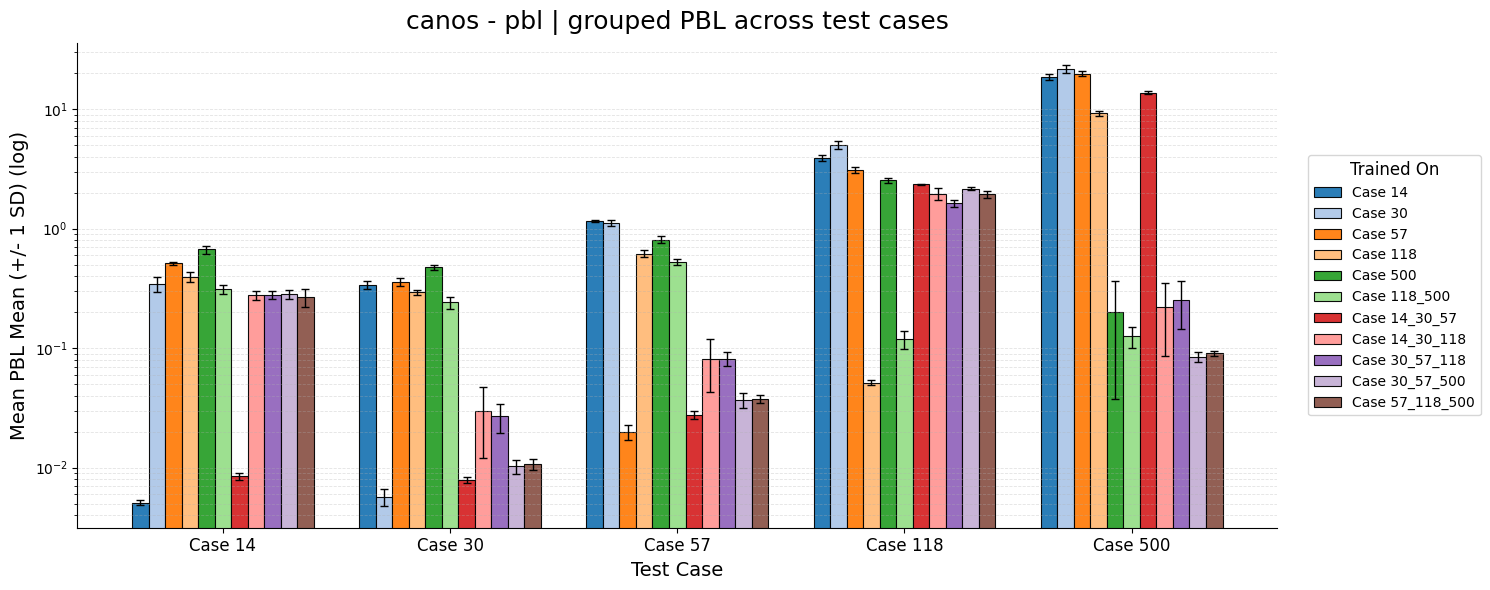

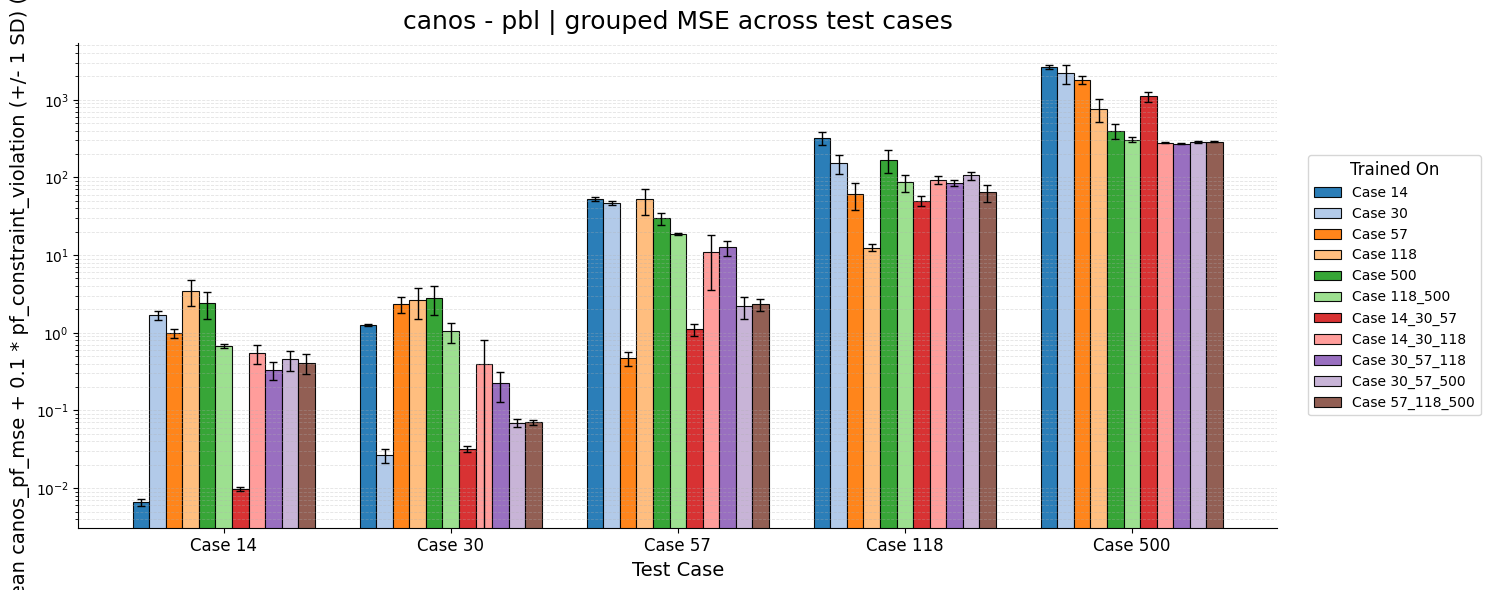

## canos - mse

,selection_metric,pbl_metric,mse_metric,train_case_rows,test_case_columns,expected_seeds
0,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,canos,mse,task31,case118,42,145,canos_pf_mse + 0.1 * pf_constraint_violation,0.225219,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
1,canos,mse,task31,case118,43,187,canos_pf_mse + 0.1 * pf_constraint_violation,0.223732,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
2,canos,mse,task31,case118,44,171,canos_pf_mse + 0.1 * pf_constraint_violation,0.131678,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
3,canos,mse,task31,case14,42,105,canos_pf_mse + 0.1 * pf_constraint_violation,0.003201,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
4,canos,mse,task31,case14,43,121,canos_pf_mse + 0.1 * pf_constraint_violation,0.003467,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
5,canos,mse,task31,case14,44,177,canos_pf_mse + 0.1 * pf_constraint_violation,0.002173,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
6,canos,mse,task31,case30,42,13,canos_pf_mse + 0.1 * pf_constraint_violation,0.115746,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
7,canos,mse,task31,case30,43,19,canos_pf_mse + 0.1 * pf_constraint_violation,0.068348,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
8,canos,mse,task31,case30,44,7,canos_pf_mse + 0.1 * pf_constraint_violation,0.114588,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...
9,canos,mse,task31,case500,42,113,canos_pf_mse + 0.1 * pf_constraint_violation,6.350844,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/mse/tas...


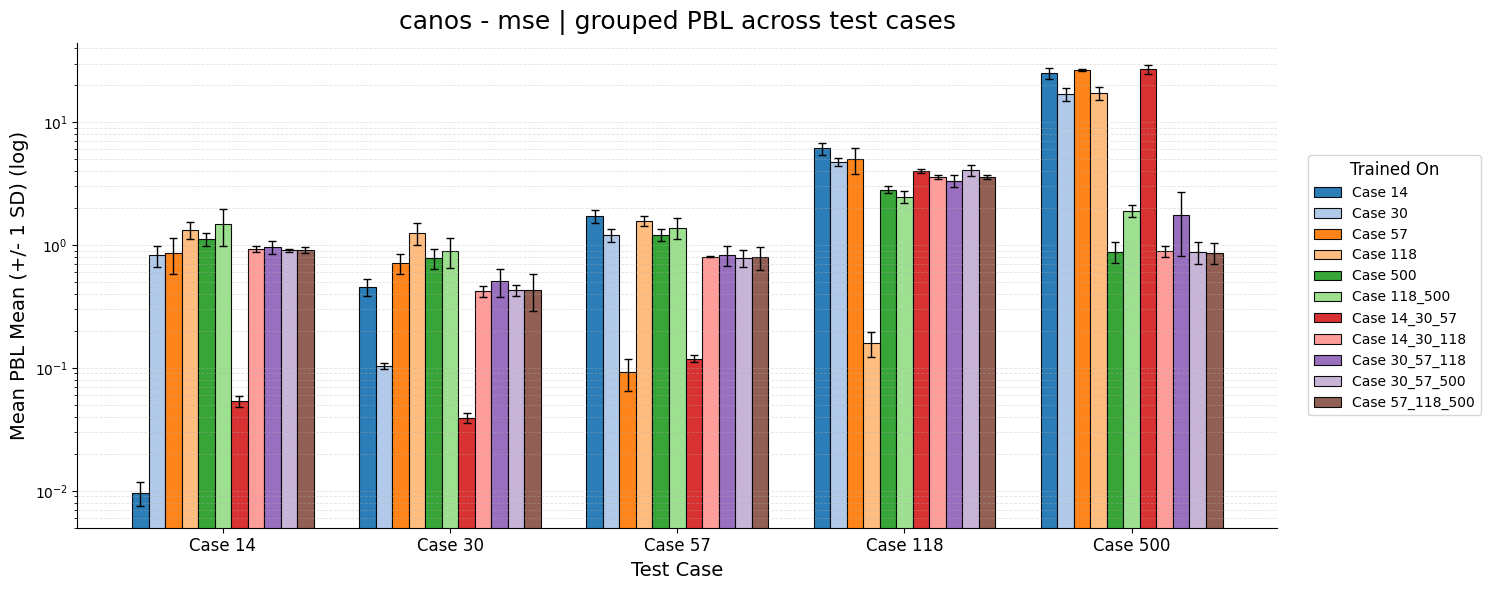

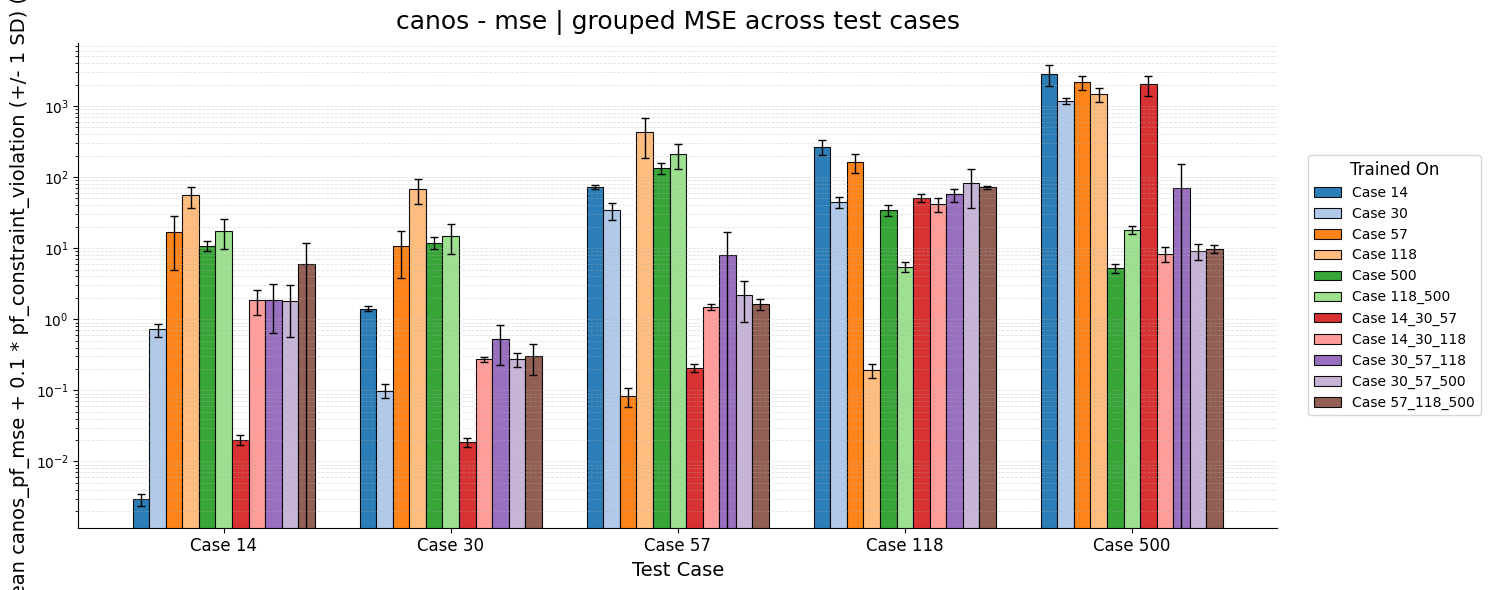

## graphconv - pbl

,selection_metric,pbl_metric,mse_metric,train_case_rows,test_case_columns,expected_seeds
0,PBL Mean,PBL Mean,MSELoss,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,graphconv,pbl,task31,case118,42,15,PBL Mean,0.286431,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
1,graphconv,pbl,task31,case118,43,37,PBL Mean,0.275144,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
2,graphconv,pbl,task31,case118,44,87,PBL Mean,0.265276,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
3,graphconv,pbl,task31,case14,42,97,PBL Mean,0.061448,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
4,graphconv,pbl,task31,case14,43,35,PBL Mean,0.062956,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
5,graphconv,pbl,task31,case14,44,77,PBL Mean,0.061771,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
6,graphconv,pbl,task31,case30,42,95,PBL Mean,0.043530,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
7,graphconv,pbl,task31,case30,43,65,PBL Mean,0.044142,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
8,graphconv,pbl,task31,case30,44,57,PBL Mean,0.044153,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
9,graphconv,pbl,task31,case500,42,29,PBL Mean,0.428237,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...


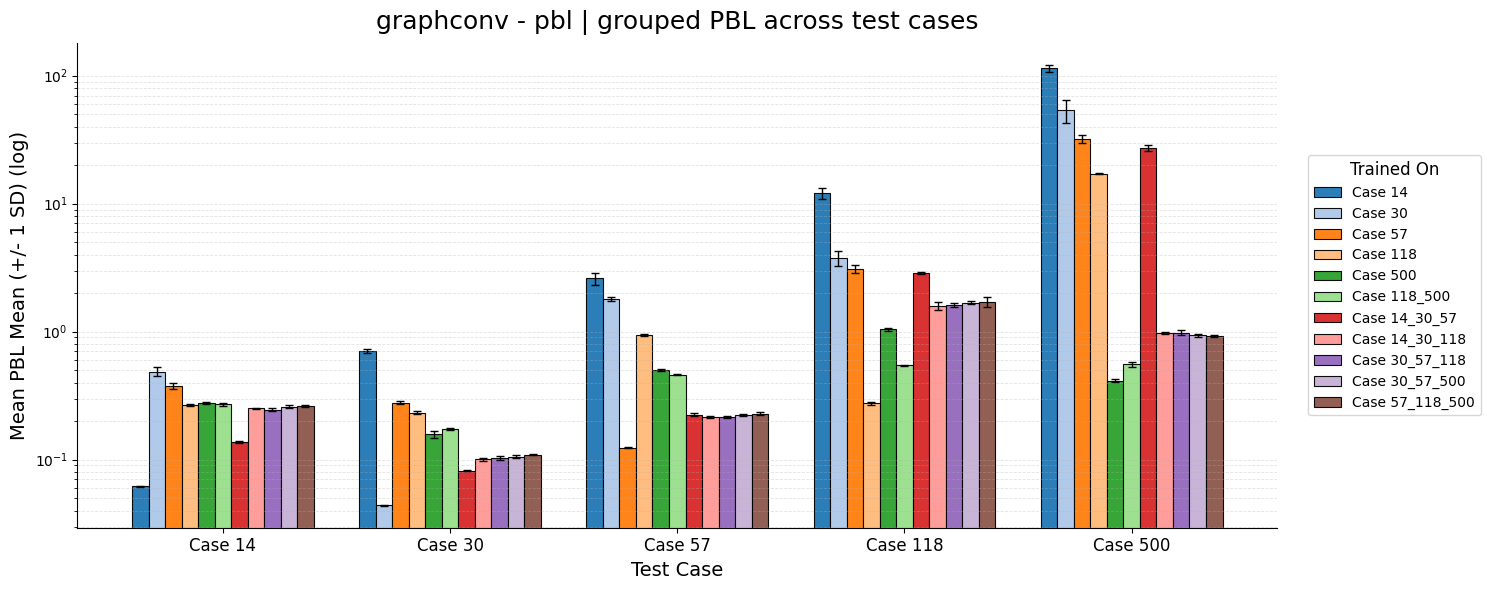

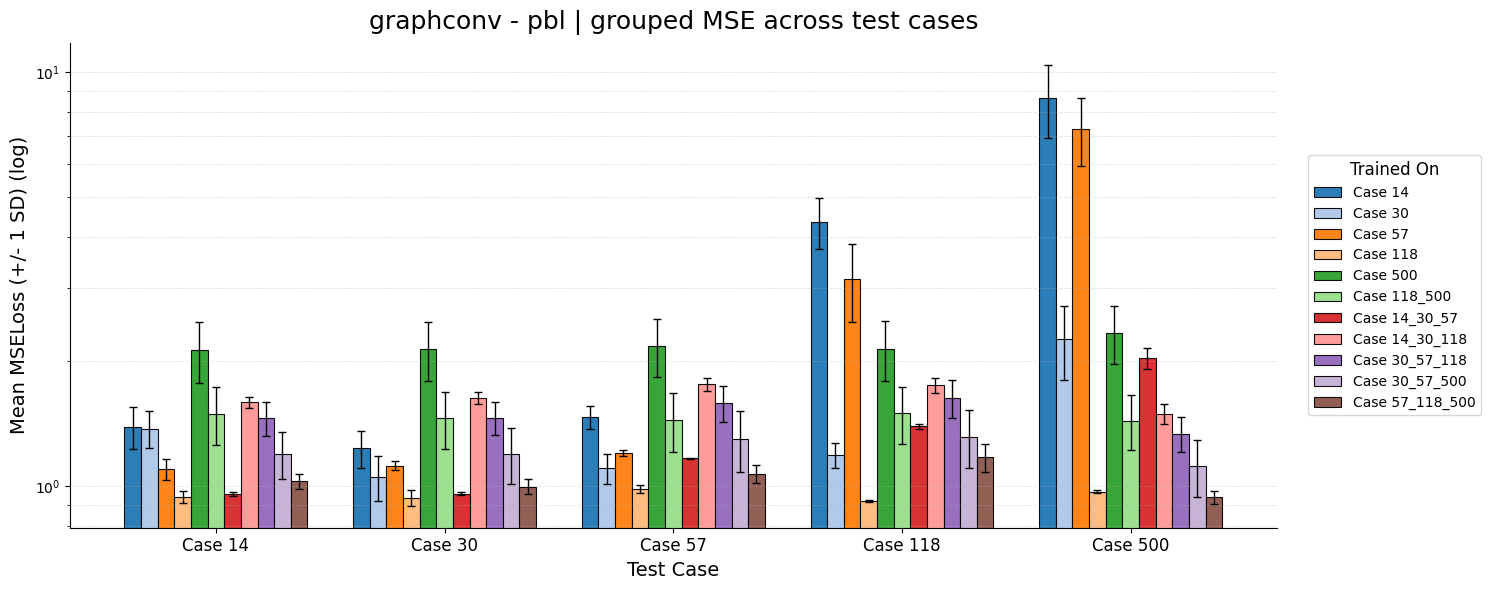

## powerflownet - pbl

,selection_metric,pbl_metric,mse_metric,train_case_rows,test_case_columns,expected_seeds
0,PBL Mean,PBL Mean,MSELoss,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,powerflownet,pbl,task31,case118,42,69,PBL Mean,0.092042,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
1,powerflownet,pbl,task31,case118,43,73,PBL Mean,0.090089,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
2,powerflownet,pbl,task31,case118,44,75,PBL Mean,0.093453,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
3,powerflownet,pbl,task31,case14,42,63,PBL Mean,0.016722,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
4,powerflownet,pbl,task31,case14,43,73,PBL Mean,0.015554,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
5,powerflownet,pbl,task31,case14,44,67,PBL Mean,0.018108,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
6,powerflownet,pbl,task31,case30,42,43,PBL Mean,0.013715,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
7,powerflownet,pbl,task31,case30,43,39,PBL Mean,0.013962,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
8,powerflownet,pbl,task31,case30,44,61,PBL Mean,0.012804,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...
9,powerflownet,pbl,task31,case500,42,63,PBL Mean,0.180135,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0326/pbl/tas...


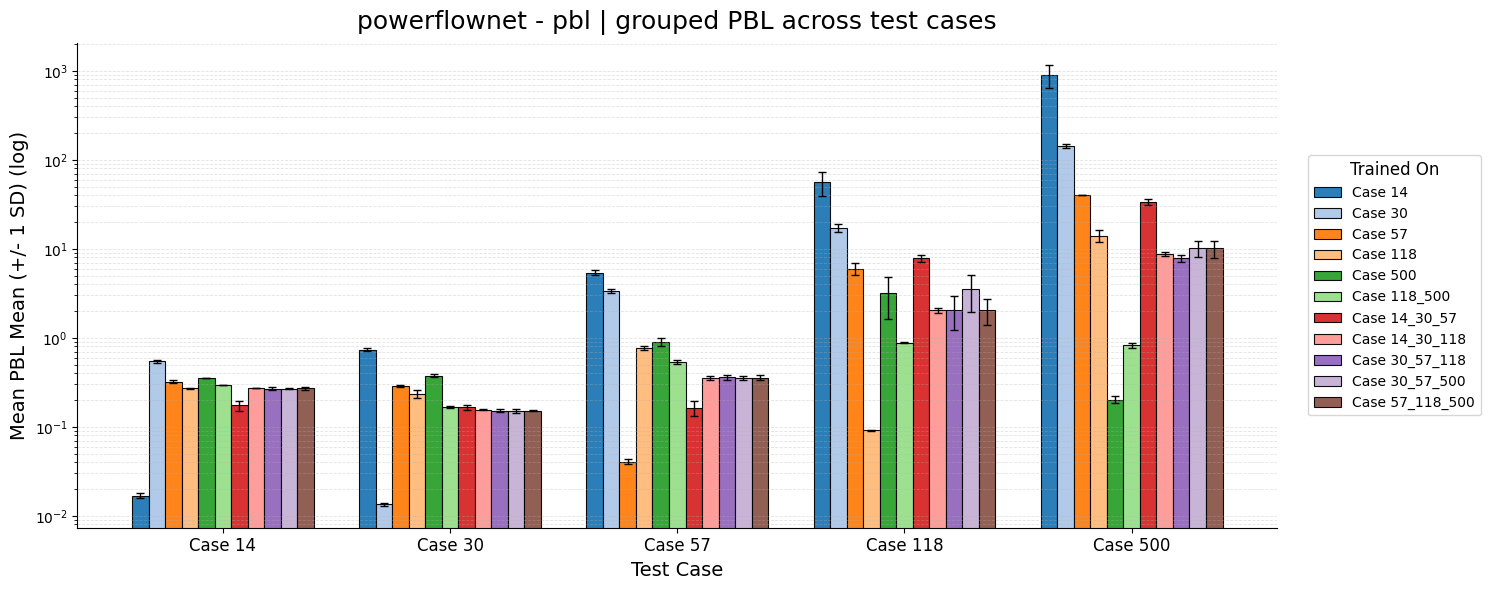

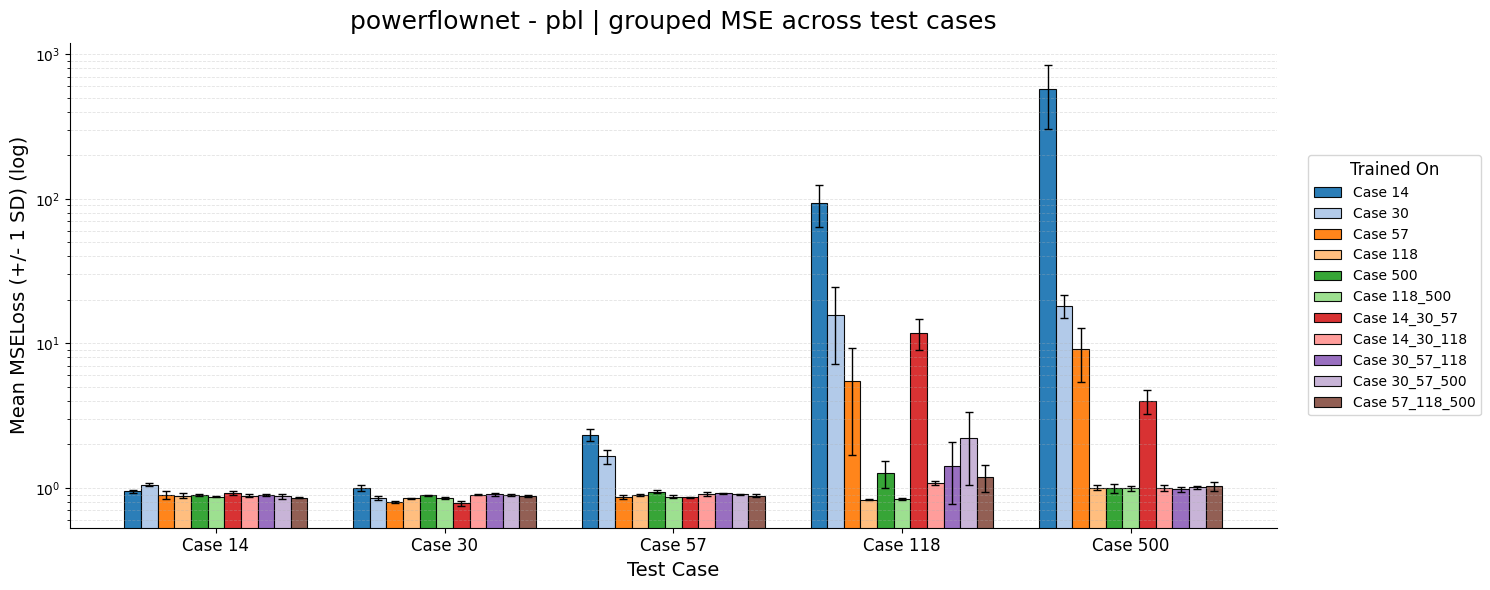

## Rendered Combo Summary

,tab_label,default_visible,selection_metric,pbl_metric,mse_metric
0,canos - pbl,PBL,PBL Mean,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation
1,canos - mse,MSE,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation
2,graphconv - pbl,PBL,PBL Mean,PBL Mean,MSELoss
3,powerflownet - pbl,PBL,PBL Mean,PBL Mean,MSELoss


In [2]:
tab_specs = []
render_summary_rows = []

for combo_key in suite_data["combo_order"]:
    combo = suite_data["combos"][combo_key]
    display(Markdown(f"## {combo['display_name']}"))

    combo_meta_df = pd.DataFrame(
        [
            {
                "selection_metric": combo["selection_metric_key"],
                "pbl_metric": combo["pbl_metric_key"],
                "mse_metric": combo["mse_metric_key"],
                "train_case_rows": len(combo["row_labels"]),
                "test_case_columns": len(combo["col_labels"]),
                "expected_seeds": ", ".join(str(seed) for seed in combo["expected_seeds"]),
            }
        ]
    )
    display(combo_meta_df)

    combo_audit_df = pd.DataFrame(combo["audit_rows"]).sort_values(
        ["task", "train_case", "seed"]
    ).reset_index(drop=True)
    display(combo_audit_df)

    pbl_data = utils.build_metric_matrices(combo, combo["pbl_metric_key"])
    mse_data = utils.build_metric_matrices(combo, combo["mse_metric_key"])

    utils.plot_grouped_bar_chart(
        pbl_data["means"],
        pbl_data["stds"],
        pbl_data["row_labels"],
        pbl_data["col_labels"],
        pbl_data["metric_label"],
        f"{combo['display_name']} | grouped PBL across test cases",
    )

    utils.plot_grouped_bar_chart(
        mse_data["means"],
        mse_data["stds"],
        mse_data["row_labels"],
        mse_data["col_labels"],
        mse_data["metric_label"],
        f"{combo['display_name']} | grouped MSE across test cases",
    )

    default_visible = "PBL" if combo["loss_family"].lower() == "pbl" else "MSE"
    combined_figure = utils.plot_metric_toggle_chart(
        pbl_data,
        mse_data,
        title=f"{combo['display_name']} | grouped PBL vs MSE across test cases",
        default_visible=default_visible,
    )

    tab_specs.append(
        {
            "label": combo["display_name"],
            "tab_id": f"{combo['model_slug']}-{combo['loss_family']}",
            "figure": combined_figure,
            "metadata": [
                ("Selection metric", combo["selection_metric_key"]),
                ("PBL metric", combo["pbl_metric_key"]),
                ("MSE metric", combo["mse_metric_key"]),
                ("Train cases", len(combo["row_labels"])),
                ("Expected seeds", ", ".join(str(seed) for seed in combo["expected_seeds"])),
            ],
        }
    )

    render_summary_rows.append(
        {
            "tab_label": combo["display_name"],
            "default_visible": default_visible,
            "selection_metric": combo["selection_metric_key"],
            "pbl_metric": combo["pbl_metric_key"],
            "mse_metric": combo["mse_metric_key"],
        }
    )

display(Markdown("## Rendered Combo Summary"))
display(pd.DataFrame(render_summary_rows))


In [3]:
written_path = utils.write_tabbed_interactive_export(
    tab_specs,
    EXPORT_PATH,
    page_title="gen_apr0326 interactive test-case charts",
)

export_df = pd.DataFrame(
    [
        {
            "export_file": "index.html",
            "repo_relative_path": str(Path(written_path).resolve().relative_to(REPO_ROOT)),
            "absolute_path": str(Path(written_path).resolve()),
            "num_tabs": len(tab_specs),
        }
    ]
)

display(Markdown("## Interactive Export"))
display(export_df)


## Interactive Export

,export_file,repo_relative_path,absolute_path,num_tabs
0,index.html,notebooks/interactive_exports/gen_apr0326/inde...,/home/osanghi/pfdelta/notebooks/interactive_ex...,4


## Re-run Export

You can re-execute this notebook and refresh the exported HTML with:

```bash
bash scripts/interactive_exports/generate_interactive_exports.sh
```
